# Лабораторная работа 2 — компактная версия

Методология:  
1. отобрать количественные признаки причины через VIF;  
2. проверить влияние категориального фактора `Сфера занятости`;  
3. построить модели `причины → состояния` с dummy-переменными для сферы занятости;  
4. отобрать состояния, которые связаны со счастьем и достаточно хорошо восстанавливаются по причинам;  
5. построить логистическую модель `предсказанные состояния → счастье`;  
6. спрогнозировать счастье для наблюдений с `Неизвестно`.


In [395]:

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scipy import stats
from scipy.stats import spearmanr, kruskal, mannwhitneyu, levene

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    classification_report,
    confusion_matrix,
    r2_score,
    mean_squared_error,
)

sns.set_theme(style="whitegrid")

DATA_PATH = Path("Вар_40_Б24-215_Варданян_Лаба2_студент.xlsx")

VIF_THRESHOLD = 10.0
PVALUE_THRESHOLD = 0.05
RHO_THRESHOLD = 0.1
R2_THRESHOLD = 0.1

USE_CAT_IN_STATE_MODELS = False
USE_CAT_IN_CLASSIFIER = False
MIN_COMMUNITY_SIZE = 20
LOCAL_MODEL_MIN_N = 40

RANDOM_STATE = 6


## 1. Загрузка данных и выделение групп признаков

In [396]:

df_raw = pd.read_excel(DATA_PATH)

CANTRIL_ORDER = [
    "Hopeless", "Depressed", "Suffering", "Strugglng", "Coping",
    "Just ok", "Doing well", "Blooming", "Thriving", "Prospering"
]

CANTRIL_COL = df_raw.columns[-1]
MARKER_UNKNOWN = "Неизвестно"

ALL_CAUSE = df_raw.columns[1:11].tolist()
INDIVIDUAL_CAUSE_COLS = ALL_CAUSE[:5]
COMMUNITY_CAUSE_COLS = ALL_CAUSE[5:10]
CAT_FEATURES = [df_raw.columns[11]]
STATE_FEATURES = df_raw.columns[12:25].tolist()

is_unknown = (
    df_raw[CANTRIL_COL].astype(str).str.strip().eq(MARKER_UNKNOWN)
    | df_raw[CANTRIL_COL].isna()
)

df_known = df_raw.loc[~is_unknown].copy()
df_unknown = df_raw.loc[is_unknown].copy()

actual_classes = [c for c in CANTRIL_ORDER if c in df_known[CANTRIL_COL].unique()]
class_to_rank = {c: i for i, c in enumerate(actual_classes)}
rank_to_class = {i: c for c, i in class_to_rank.items()}

df_known["rank"] = df_known[CANTRIL_COL].map(class_to_rank)

df_train, df_test = train_test_split(
    df_known,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=df_known["rank"]
)

print(f"known: {df_known.shape}, unknown: {df_unknown.shape}")
print(f"train: {df_train.shape}, test: {df_test.shape}")
print(f"причин: {len(ALL_CAUSE)}, состояний: {len(STATE_FEATURES)}, категорий: {len(CAT_FEATURES)}")


known: (1900, 27), unknown: (600, 26)
train: (1615, 27), test: (285, 27)
причин: 10, состояний: 13, категорий: 1


## 2. VIF для количественных признаков причины

In [397]:

def compute_vif(X_df):
    X = X_df.copy().fillna(X_df.median())
    X_const = sm.add_constant(X, has_constant="add")
    vals = [
        variance_inflation_factor(X_const.values, i)
        for i in range(1, X_const.shape[1])
    ]
    return (
        pd.DataFrame({"feature": X.columns, "VIF": vals})
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )

current_cols = ALL_CAUSE.copy()

while True:
    vif_df = compute_vif(df_train[current_cols])
    worst = vif_df.iloc[0]
    if worst["VIF"] <= VIF_THRESHOLD:
        break
    current_cols.remove(worst["feature"])

display(vif_df)
print("Оставлены причины:", len(current_cols))


,feature,VIF
0,Количество смертей от вирусных и респираторных...,3.355223
1,Доля от дохода семьи которая тратится на продо...,2.943819
2,"Охват беспроводной связи в сообществе, %",2.843195
3,Количество лет образования,2.800934
4,Коэффициент Джини сообщества,1.978035
5,"Среднегодовой доход, тыс. $",1.731644
6,Количество членов семьи,1.218531
7,"Объем потребленного алкоголя в год, л.",1.053628


Оставлены причины: 8


## 3. Влияние категориального фактора `Сфера занятости` на состояния

In [398]:

cat_test_rows = []

for cat_col in CAT_FEATURES:
    for state_col in STATE_FEATURES:
        groups = [
            g[state_col].dropna()
            for _, g in df_train.groupby(cat_col)
            if g[state_col].dropna().shape[0] >= 5
        ]

        if len(groups) == 2:
            pval = mannwhitneyu(groups[0], groups[1], alternative="two-sided").pvalue
            test_name = "Mann-Whitney"
        elif len(groups) > 2:
            pval = kruskal(*groups).pvalue
            test_name = "Kruskal-Wallis"
        else:
            continue

        cat_test_rows.append({
            "category": cat_col,
            "state": state_col,
            "test": test_name,
            "p-value": pval,
            "significant": pval < PVALUE_THRESHOLD
        })

cat_tests = pd.DataFrame(cat_test_rows)

display(
    cat_tests[cat_tests["significant"]]
    .sort_values("p-value")
    .reset_index(drop=True)
)

# Таблица медиан для значимых состояний: нужна для интерпретации, какие группы отличаются.
significant_cat_states = cat_tests.loc[cat_tests["significant"], "state"].unique().tolist()

for cat_col in CAT_FEATURES:
    cat_medians = {}
    for state_col in significant_cat_states:
        cat_medians[state_col] = (
            df_train
            .groupby(cat_col)[state_col]
            .agg(["count", "median", "mean"])
            .sort_values("median", ascending=False)
        )

    print("Сохранено таблиц медиан:", len(cat_medians))


,category,state,test,p-value,significant
0,Сфера занятости,Чувство неравенства доходов в обществе,Kruskal-Wallis,1.415916e-08,True
1,Сфера занятости,Оценка социальной поддержки,Kruskal-Wallis,2.011969e-04,True


Сохранено таблиц медиан: 2


## 4. Отбор состояний по связи со счастьем

In [399]:

corr_rows = []

for state_col in STATE_FEATURES:
    valid = df_train[[state_col, "rank"]].dropna()
    if len(valid) < 10:
        continue

    rho, pval = spearmanr(valid[state_col], valid["rank"])
    corr_rows.append({"state": state_col, "Spearman": rho, "p-value": pval})

state_corr = (
    pd.DataFrame(corr_rows)
    .sort_values("Spearman", key=abs, ascending=False)
    .reset_index(drop=True)
)

selected_state = state_corr.loc[
    (state_corr["p-value"] < PVALUE_THRESHOLD)
    & (state_corr["Spearman"].abs() >= RHO_THRESHOLD),
    "state"
].tolist()

display(state_corr)
print("Отобранные состояния:", *selected_state, sep="\n- ")


,state,Spearman,p-value
0,Свобода граждан самостоятельно принимать жизне...,0.670856,1.103682e-211
1,Ожидаемая продолжительность здоровой жизни,0.546107,3.271365e-126
2,Индекс страха социальных конфликтов,0.353777,8.194855e-49
3,Оценка благополучия,0.315850,9.675319e-39
4,Чувство неравенства доходов в обществе,0.126273,3.561396e-07
5,Оценка риска безработицы,0.100622,5.102638e-05
6,Индекс продовольственной безопасности,0.081779,1.003992e-03
7,Чувство технологического прогресса,-0.051599,3.813700e-02
8,Индекс семьи,0.027239,2.739495e-01
9,Индекс кредитного оптимизма,0.026159,2.934363e-01


Отобранные состояния:
- Свобода граждан самостоятельно принимать жизненно важные решения
- Ожидаемая продолжительность здоровой жизни
- Индекс страха социальных конфликтов
- Оценка благополучия
- Чувство неравенства доходов в обществе
- Оценка риска безработицы


## 5. Модели `причины → состояния` с dummy-переменными сферы занятости

In [400]:

CAT_LEVELS = {
    c: sorted(df_train[c].dropna().unique().tolist())
    for c in CAT_FEATURES
}

def make_cat_dummies(source_df):
    parts = []
    for c in CAT_FEATURES:
        s = pd.Categorical(source_df[c], categories=CAT_LEVELS[c])
        parts.append(pd.get_dummies(s, prefix=c, drop_first=True, dtype=float))
    return pd.concat(parts, axis=1).reset_index(drop=True) if parts else pd.DataFrame(index=range(len(source_df)))


def make_state_X(train_df, source_df, feature_cols=None, use_cat=USE_CAT_IN_STATE_MODELS):
    X_num = (
        source_df[current_cols]
        .fillna(train_df[current_cols].median())
        .reset_index(drop=True)
    )

    parts = [X_num]

    if use_cat and CAT_FEATURES:
        parts.append(make_cat_dummies(source_df))

    X = pd.concat(parts, axis=1)

    if feature_cols is not None:
        X = X.reindex(columns=feature_cols, fill_value=0)

    return sm.add_constant(X, has_constant="add")


def fit_state_model(train_df, state_col, use_cat=USE_CAT_IN_STATE_MODELS):
    valid = train_df.dropna(subset=[state_col]).copy()

    X = make_state_X(valid, valid, use_cat=use_cat)
    y = valid[state_col].reset_index(drop=True)

    base_model = sm.OLS(y, X).fit()
    shapiro_p = stats.shapiro(base_model.resid)[1] if len(base_model.resid) <= 5000 else np.nan
    bp_p = sms.het_breuschpagan(base_model.resid, X)[1]

    normal_bad = (not np.isnan(shapiro_p)) and (shapiro_p < PVALUE_THRESHOLD)
    hetero = bp_p < PVALUE_THRESHOLD

    if normal_bad:
        model = sm.RLM(y, X, M=sm.robust.norms.HuberT()).fit(cov="H3" if hetero else "H1")
        model_type = "RLM Huber + H3" if hetero else "RLM Huber"
    elif hetero:
        model = sm.OLS(y, X).fit(cov_type="HC3")
        model_type = "OLS + HC3"
    else:
        model = base_model
        model_type = "OLS"

    pred = np.asarray(model.predict(X))
    r2_val = np.corrcoef(y, pred)[0, 1] ** 2 if np.std(pred) > 0 else 0

    return {
        "model": model,
        "features": [c for c in X.columns if c != "const"],
        "rsquared": r2_val,
        "model_type": model_type,
        "shapiro_p": shapiro_p,
        "bp_p": bp_p,
        "use_cat": use_cat,
    }


def predict_state(model_info, train_df, source_df):
    X = make_state_X(
        train_df,
        source_df,
        feature_cols=model_info["features"],
        use_cat=model_info["use_cat"]
    )
    return pd.Series(np.asarray(model_info["model"].predict(X)), index=source_df.index)


state_models = {s: fit_state_model(df_train, s) for s in selected_state}

state_model_table = (
    pd.DataFrame([
        {
            "state": s,
            "R2": info["rsquared"],
            "model": info["model_type"],
            "Shapiro p": info["shapiro_p"],
            "Breusch-Pagan p": info["bp_p"],
        }
        for s, info in state_models.items()
    ])
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)

final_states = state_model_table.loc[
    state_model_table["R2"] >= R2_THRESHOLD,
    "state"
].tolist()

display(state_model_table)
print("Финальные состояния:", *final_states, sep="\n- ")


,state,R2,model,Shapiro p,Breusch-Pagan p
0,Чувство неравенства доходов в обществе,0.937254,RLM Huber + H3,7.092616e-06,2.787736e-04
1,Ожидаемая продолжительность здоровой жизни,0.705377,OLS,3.323714e-01,7.898569e-01
2,Индекс страха социальных конфликтов,0.705330,OLS,8.670243e-01,1.027618e-01
3,Оценка благополучия,0.651225,RLM Huber + H3,3.830688e-28,1.211234e-57
4,Свобода граждан самостоятельно принимать жизне...,0.421431,RLM Huber + H3,1.828066e-17,2.236602e-32
5,Оценка риска безработицы,0.289522,RLM Huber + H3,6.907658e-29,7.222692e-32


Финальные состояния:
- Чувство неравенства доходов в обществе
- Ожидаемая продолжительность здоровой жизни
- Индекс страха социальных конфликтов
- Оценка благополучия
- Свобода граждан самостоятельно принимать жизненно важные решения
- Оценка риска безработицы


## 6. Out-of-fold прогнозы состояний

In [401]:

def build_state_predictions(final_states):
    oof_train = pd.DataFrame(index=df_train.index, columns=final_states, dtype=float)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for tr_idx, val_idx in skf.split(df_train, df_train["rank"]):
        fold_train = df_train.iloc[tr_idx].copy()
        fold_valid = df_train.iloc[val_idx].copy()

        for state_col in final_states:
            fold_model = fit_state_model(fold_train, state_col)
            oof_train.loc[fold_valid.index, state_col] = predict_state(
                fold_model,
                fold_train,
                fold_valid
            )

    pred_test = pd.DataFrame(index=df_test.index)
    pred_unknown = pd.DataFrame(index=df_unknown.index)

    for state_col in final_states:
        pred_test[state_col] = predict_state(state_models[state_col], df_train, df_test)
        pred_unknown[state_col] = predict_state(state_models[state_col], df_train, df_unknown)

    return oof_train, pred_test, pred_unknown


state_pred_train, state_pred_test, state_pred_unknown = build_state_predictions(final_states)

print("state_pred_train:", state_pred_train.shape)
print("state_pred_test: ", state_pred_test.shape)
print("state_pred_unknown:", state_pred_unknown.shape)


state_pred_train: (1615, 6)
state_pred_test:  (285, 6)
state_pred_unknown: (600, 6)


## 7. Проверка связи остатков с обществами

In [402]:

def add_community_id(source_df, mapping=None):
    result = source_df.copy()
    keys = (
        result[COMMUNITY_CAUSE_COLS]
        .round(8)
        .astype(str)
        .agg("|".join, axis=1)
    )

    if mapping is None:
        categories = pd.Categorical(keys)
        mapping = dict(zip(categories.categories, range(len(categories.categories))))
        result["_community_id"] = keys.map(mapping).astype(int)
        return result, mapping

    result["_community_id"] = keys.map(mapping).fillna(-1).astype(int)
    return result


df_train_comm, community_mapping = add_community_id(df_train)
df_test_comm = add_community_id(df_test, community_mapping)
df_unknown_comm = add_community_id(df_unknown, community_mapping)

residual_rows = []

for state_col in final_states:
    valid = df_train_comm.dropna(subset=[state_col]).copy()
    pred = predict_state(state_models[state_col], df_train, valid)
    resid = valid[state_col] - pred

    residual_rows.append(pd.DataFrame({
        "state": state_col,
        "community_id": valid["_community_id"].values,
        "resid": resid.values,
        "abs_resid": np.abs(resid.values),
        "sq_resid": resid.values ** 2,
    }))

resid_long = pd.concat(residual_rows, ignore_index=True)

community_resid_summary = (
    resid_long
    .groupby(["state", "community_id"])
    .agg(
        n=("resid", "size"),
        mean_resid=("resid", "mean"),
        mean_abs_resid=("abs_resid", "mean"),
        rmse=("sq_resid", lambda x: np.sqrt(np.mean(x))),
    )
    .reset_index()
)

community_resid_summary = community_resid_summary[
    community_resid_summary["n"] >= MIN_COMMUNITY_SIZE
]

resid_tests = []

for state_col in final_states:
    part = resid_long[resid_long["state"] == state_col].copy()

    valid_ids = (
        part["community_id"]
        .value_counts()
        .loc[lambda s: s >= MIN_COMMUNITY_SIZE]
        .index
    )

    part = part[part["community_id"].isin(valid_ids)]

    if part["community_id"].nunique() < 2:
        continue

    signed_groups = [g["resid"].values for _, g in part.groupby("community_id")]
    abs_groups = [g["abs_resid"].values for _, g in part.groupby("community_id")]

    resid_tests.append({
        "state": state_col,
        "n_communities": part["community_id"].nunique(),
        "Kruskal signed residuals p": kruskal(*signed_groups).pvalue,
        "Kruskal abs residuals p": kruskal(*abs_groups).pvalue,
        "Levene variance p": levene(*signed_groups, center="median").pvalue,
    })

resid_tests_df = (
    pd.DataFrame(resid_tests)
    .sort_values("Levene variance p")
    .reset_index(drop=True)
)

display(resid_tests_df)
display(
    community_resid_summary
    .sort_values(["state", "rmse"], ascending=[True, False])
)


,state,n_communities,Kruskal signed residuals p,Kruskal abs residuals p,Levene variance p
0,Оценка риска безработицы,25,8.479829e-25,6.425754e-41,2.912747e-175
1,Свобода граждан самостоятельно принимать жизне...,25,3.427416e-135,4.077989e-69,5.878429e-55
2,Индекс страха социальных конфликтов,25,4.342796e-62,7.954385e-09,6.074543e-02
3,Ожидаемая продолжительность здоровой жизни,25,4.198188e-01,6.256411e-02,7.792498e-02
4,Оценка благополучия,25,4.598428e-87,1.015478e-35,3.229231e-01
5,Чувство неравенства доходов в обществе,25,1.501480e-70,2.752442e-11,5.706341e-01


,state,community_id,n,mean_resid,mean_abs_resid,rmse
8,Индекс страха социальных конфликтов,8,26,12.407008,13.576988,17.210181
13,Индекс страха социальных конфликтов,13,39,-11.359742,12.883155,15.848265
21,Индекс страха социальных конфликтов,21,32,-10.220265,11.752632,13.628199
2,Индекс страха социальных конфликтов,2,63,-8.594369,10.933144,13.444531
9,Индекс страха социальных конфликтов,9,90,10.110225,11.147938,13.221136
...,...,...,...,...,...,...
126,Чувство неравенства доходов в обществе,1,83,-0.524179,3.040930,3.957949
128,Чувство неравенства доходов в обществе,3,45,-1.014762,3.211845,3.820331
145,Чувство неравенства доходов в обществе,20,84,-0.543074,2.917093,3.749545
141,Чувство неравенства доходов в обществе,16,37,1.141970,2.608149,3.715267


## 8. Проверка локальных моделей внутри обществ

In [403]:

def make_local_X(train_df, source_df, feature_cols=None):
    X_num = (
        source_df[INDIVIDUAL_CAUSE_COLS]
        .fillna(train_df[INDIVIDUAL_CAUSE_COLS].median())
        .reset_index(drop=True)
    )

    X = pd.concat([X_num, make_cat_dummies(source_df)], axis=1)

    if feature_cols is not None:
        X = X.reindex(columns=feature_cols, fill_value=0)

    return sm.add_constant(X, has_constant="add")


def predict_hybrid_state(train_df, source_df, state_col, global_model_info, min_n=LOCAL_MODEL_MIN_N):
    train_comm, mapping = add_community_id(train_df)
    source_comm = add_community_id(source_df, mapping)

    pred = predict_state(global_model_info, train_df, source_df).copy()

    for community_id, source_part in source_comm.groupby("_community_id"):
        if community_id == -1:
            continue

        local_train = train_comm[
            train_comm["_community_id"] == community_id
        ].dropna(subset=[state_col])

        if len(local_train) < min_n:
            continue

        X_local = make_local_X(local_train, local_train)
        y_local = local_train[state_col].reset_index(drop=True)

        try:
            local_model = sm.OLS(y_local, X_local).fit()
            X_source = make_local_X(
                local_train,
                source_part,
                feature_cols=[c for c in X_local.columns if c != "const"]
            )
            pred.loc[source_part.index] = np.asarray(local_model.predict(X_source))
        except Exception:
            pass

    return pred


hybrid_rows = []

for state_col in final_states:
    y_true = df_test[state_col]
    mask = y_true.notna()

    pred_global = state_pred_test[state_col]
    pred_hybrid = predict_hybrid_state(
        df_train,
        df_test,
        state_col,
        state_models[state_col]
    )

    hybrid_rows.append({
        "state": state_col,
        "R2 global": r2_score(y_true[mask], pred_global[mask]),
        "R2 hybrid": r2_score(y_true[mask], pred_hybrid[mask]),
        "RMSE global": np.sqrt(mean_squared_error(y_true[mask], pred_global[mask])),
        "RMSE hybrid": np.sqrt(mean_squared_error(y_true[mask], pred_hybrid[mask])),
    })

hybrid_quality = pd.DataFrame(hybrid_rows)
hybrid_quality["delta R2"] = hybrid_quality["R2 hybrid"] - hybrid_quality["R2 global"]
hybrid_quality["delta RMSE"] = hybrid_quality["RMSE hybrid"] - hybrid_quality["RMSE global"]

display(hybrid_quality.sort_values("delta R2", ascending=False))


,state,R2 global,R2 hybrid,RMSE global,RMSE hybrid,delta R2,delta RMSE
4,Свобода граждан самостоятельно принимать жизне...,0.390143,0.893658,10.772094,4.498187,0.503516,-6.273907
5,Оценка риска безработицы,0.383800,0.589511,9.277814,7.572437,0.205711,-1.705376
3,Оценка благополучия,0.659783,0.851813,7.752672,5.116570,0.192029,-2.636102
0,Чувство неравенства доходов в обществе,0.920967,0.962112,5.514328,3.818050,0.041145,-1.696278
2,Индекс страха социальных конфликтов,0.717756,0.735595,10.746300,10.401157,0.017839,-0.345143
1,Ожидаемая продолжительность здоровой жизни,0.731691,0.704459,8.558190,8.982015,-0.027233,0.423824


## 9. Логистическая модель счастья

,scenario,micro precision,params
0,"Диагностика: реальные состояния | C=3.0, class...",0.971930,"{'C': 3.0, 'class_weight': None}"
1,"Реалистично: предсказанные состояния | C=3.0, ...",0.719298,"{'C': 3.0, 'class_weight': None}"


Финальная реалистичная micro precision: 0.719
Критерий ВЫПОЛНЕН
              precision    recall  f1-score   support

    Hopeless       1.00      0.92      0.96        12
   Depressed       0.87      0.87      0.87        15
   Suffering       0.64      0.78      0.71        46
   Strugglng       1.00      1.00      1.00        13
      Coping       0.69      0.89      0.77        27
     Just ok       0.66      0.60      0.63        35
  Doing well       0.64      0.65      0.64        43
    Blooming       0.67      0.41      0.51        44
    Thriving       0.74      0.79      0.76        33
  Prospering       0.88      0.88      0.88        17

    accuracy                           0.72       285
   macro avg       0.78      0.78      0.77       285
weighted avg       0.72      0.72      0.71       285



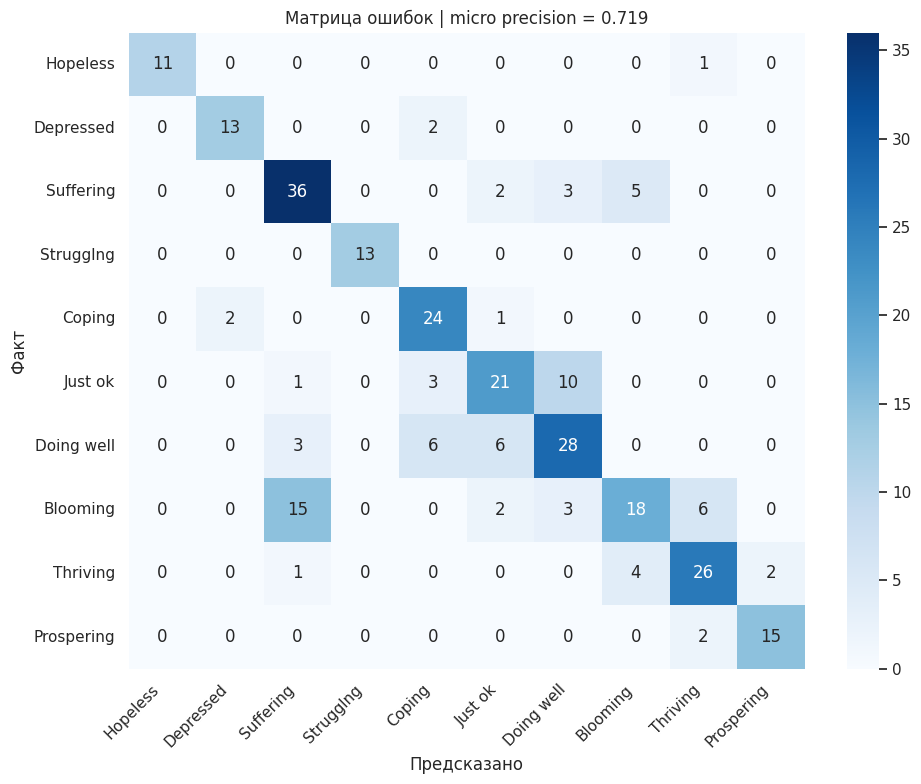

In [404]:

def make_clf_X(
    source_df,
    state_predictions=None,
    state_cols=None,
    use_real_states=False,
    train_cols=None
):
    parts = []

    if use_real_states:
        parts.append(
            source_df[final_states]
            .fillna(df_train[final_states].median())
            .reset_index(drop=True)
        )
    elif state_predictions is not None and state_cols is not None:
        parts.append(state_predictions[state_cols].reset_index(drop=True))

    if USE_CAT_IN_CLASSIFIER and CAT_FEATURES:
        parts.append(make_cat_dummies(source_df))

    X = pd.concat(parts, axis=1)

    if train_cols is not None:
        X = X.reindex(columns=train_cols, fill_value=0)

    return X


def fit_best_logreg(model_name, X_train, y_train, X_test, y_test):
    candidates = []

    for C in [0.1, 0.3, 1.0, 3.0]:
        for class_weight in [None, "balanced"]:
            model = Pipeline([
                ("scaler", StandardScaler()),
                ("classifier", LogisticRegression(
                    solver="lbfgs",
                    penalty="l2",
                    C=C,
                    class_weight=class_weight,
                    max_iter=3000,
                    random_state=42,
                ))
            ])

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            candidates.append({
                "name": f"{model_name} | C={C}, class_weight={class_weight}",
                "model": model,
                "y_pred": y_pred,
                "micro": precision_score(y_test, y_pred, average="micro"),
                "params": {"C": C, "class_weight": class_weight}
            })

    return sorted(candidates, key=lambda x: x["micro"], reverse=True)[0]


y_train = df_train["rank"].values
y_test = df_test["rank"].values

X_real_train = make_clf_X(df_train, use_real_states=True)
real_cols = X_real_train.columns.tolist()
X_real_test = make_clf_X(df_test, use_real_states=True, train_cols=real_cols)

X_pred_train = make_clf_X(df_train, state_pred_train, final_states)
pred_cols = X_pred_train.columns.tolist()
X_pred_test = make_clf_X(df_test, state_pred_test, final_states, train_cols=pred_cols)
X_pred_unknown = make_clf_X(df_unknown, state_pred_unknown, final_states, train_cols=pred_cols)

real_result = fit_best_logreg(
    "Диагностика: реальные состояния",
    X_real_train,
    y_train,
    X_real_test,
    y_test
)

pred_result = fit_best_logreg(
    "Реалистично: предсказанные состояния",
    X_pred_train,
    y_train,
    X_pred_test,
    y_test
)

quality_table = pd.DataFrame([
    {"scenario": real_result["name"], "micro precision": real_result["micro"], "params": real_result["params"]},
    {"scenario": pred_result["name"], "micro precision": pred_result["micro"], "params": pred_result["params"]},
])

display(quality_table)

clf_pipeline = pred_result["model"]
y_pred_labels = pred_result["y_pred"]
micro_prec = pred_result["micro"]

print(f"Финальная реалистичная micro precision: {micro_prec:.3f}")
print("Критерий", "ВЫПОЛНЕН" if micro_prec > 0.6 else "НЕ выполнен")

print(classification_report(
    y_test,
    y_pred_labels,
    labels=sorted(np.unique(y_test)),
    target_names=[rank_to_class[i] for i in sorted(np.unique(y_test))],
    zero_division=0
))

cm = confusion_matrix(y_test, y_pred_labels, labels=sorted(np.unique(y_test)))

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[rank_to_class[i] for i in sorted(np.unique(y_test))],
    yticklabels=[rank_to_class[i] for i in sorted(np.unique(y_test))],
)
plt.xlabel("Предсказано")
plt.ylabel("Факт")
plt.title(f"Матрица ошибок | micro precision = {micro_prec:.3f}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 10. Прогноз unknown

In [405]:

df_unknown_predicted = df_unknown.copy()

unknown_pred = clf_pipeline.predict(X_pred_unknown)
unknown_probs = clf_pipeline.predict_proba(X_pred_unknown)

df_unknown_predicted["Predicted_Happiness"] = unknown_pred
df_unknown_predicted["Predicted_Class"] = df_unknown_predicted["Predicted_Happiness"].map(rank_to_class)

for i, class_idx in enumerate(clf_pipeline.named_steps["classifier"].classes_):
    class_name = rank_to_class.get(int(class_idx), f"Class_{class_idx}")
    df_unknown_predicted[f"Prob_{class_name}"] = np.round(unknown_probs[:, i], 3)

output_path = Path("predicted_happiness_compact.xlsx")
df_unknown_predicted.to_excel(output_path, index=False)

print("Файл сохранен:", output_path)
display(df_unknown_predicted[["ID", "Predicted_Class"]].head())

# Сортируем выдачу в логическом порядке шкалы Кантрила
vc = df_unknown_predicted["Predicted_Class"].value_counts()
display(vc.reindex([c for c in CANTRIL_ORDER if c in vc.index]))


Файл сохранен: predicted_happiness_compact.xlsx


,ID,Predicted_Class
4,5,Thriving
5,6,Suffering
6,7,Blooming
10,11,Blooming
11,12,Just ok


Predicted_Class
Hopeless      28
Depressed     45
Suffering     99
Strugglng     22
Coping        63
Just ok       60
Doing well    96
Blooming      56
Thriving      98
Prospering    33
Name: count, dtype: int64

## Краткий вывод

- VIF применяется к количественным признакам причины перед построением моделей `причины → состояния`.
- `Сфера занятости` включена в модели состояния через dummy-переменные, потому что тесты показали значимое влияние на часть состояний.
- Состояния отбираются по двум критериям: связь со счастьем и качество восстановления по причинам.
- Повторный VIF для предсказанных состояний обычно не нужен: в финальной логистической модели используются только предсказанные состояния и категориальный фактор.
- Анализ остатков по обществам нужен, чтобы понять, не связана ли гетероскедастичность с групповой структурой данных.
- Локальные модели по обществам стоит применять только если они улучшают качество на test; иначе глобальная модель надежнее.
